In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simple Neural Network for Regression (NumPy only)

In [9]:
# Input: x, Hidden layer: z = ReLU(A1 x + b1), Output: y_pred = A2 z + b2

In [2]:
def relu(v):
    return np.maximum(0, v)

In [ ]:
def forward(x, A1, b1, A2, b2):
    u = A1 @ x + b1       # pre-activation: (m, B)
    z = relu(u)            # hidden layer output: (m, B)
    y_pred = A2 @ z + b2  # output: (1, B)
    return y_pred, z, u

In [ ]:
def backpropagation(x, u, z, y, y_pred, A2):
    """
    shape for each input:
    x: (n, B)
    u: (m, B)  pre-activation 
    z: (m, B)  post-activation
    y: (1, B)
    y_pred: predictions
    A2: (1, m)
    """
    B = x.shape[1]

    # dL/dy_pred = 2*(y_pred - y) / B,  shape: (1, B)
    dL_dy = 2 * (y_pred - y) / B

    # dL/dA2 = dL/dy_pred @ z.T,  shape: (1, B) @ (B, m) = (1, m)
    grad_A2 = dL_dy @ z.T

    # dL/db2 = sum over batch of dL/dy_pred,  shape: (1, 1)
    grad_b2 = dL_dy.sum(axis=1, keepdims=True)

    # dL/dz = A2.T @ dL/dy_pred,  shape: (m, 1) @ (1, B) = (m, B)
    dL_dz = A2.T @ dL_dy

    # dL/du = dL/dz * ReLU'(u),  ReLU'(u) = 1 if u > 0 else 0,  shape: (m, B)
    dL_du = dL_dz * (u > 0).astype(float)

    # dL/dA1 = dL/du @ x.T,  shape: (m, B) @ (B, n) = (m, n)
    grad_A1 = dL_du @ x.T

    # dL/db1 = sum over batch of dL/du,  shape: (m, 1)
    grad_b1 = dL_du.sum(axis=1, keepdims=True)

    return grad_A1, grad_b1, grad_A2, grad_b2

In [ ]:
def fit_neural_net(x, y, m, training_ratio=0.9, num_epochs=100, batch_size=16, lr=0.001, random_seed=42):
    """
    Train the neural network with mini-batch SGD.

    Args:
        x:              (N, n)  input features
        y:              (N, 1)  regression targets
        m:              int     hidden layer size
        training_ratio: float   fraction of data used for training
        num_epochs:     int     number of full passes over training data
        batch_size:     int     samples per gradient update
        lr:             float   learning rate
        random_seed:    int

    Returns:
        A1, b1, A2, b2          trained parameters
        losses_train, losses_val  MSE per epoch
    """
    np.random.seed(random_seed)
    N, n = x.shape

    # Shuffle entire dataset before splitting
    idx = np.random.permutation(N)
    x, y = x[idx], y[idx]

    # Train / validation split
    n_train = int(N * training_ratio)
    x_train, y_train = x[:n_train], y[:n_train]
    x_val,   y_val   = x[n_train:], y[n_train:]

    # using He initialisation
    A1 = np.random.randn(m, n) * np.sqrt(2 / n)
    b1 = np.zeros((m, 1))
    A2 = np.random.randn(1, m) * np.sqrt(2 / m)
    b2 = np.zeros((1, 1))

    losses_train, losses_val = [], []
    n_batches = n_train // batch_size  # drop the last incomplete batch

    for epoch in range(num_epochs):
        # Re-shuffle training data at the start of each epoch
        idx = np.random.permutation(n_train)
        x_train, y_train = x_train[idx], y_train[idx]

        for i in range(n_batches):
            # Slice mini-batch; transpose to (n, B) / (1, B) for matrix ops
            bx = x_train[i*batch_size:(i+1)*batch_size].T   # (n, B)
            by = y_train[i*batch_size:(i+1)*batch_size].T   # (1, B)

            y_pred, z, u = forward(bx, A1, b1, A2, b2)
            grad_A1, grad_b1, grad_A2, grad_b2 = backpropagation(bx, u, z, by, y_pred, A2)

            # Gradient descent update
            A1 -= lr * grad_A1
            b1 -= lr * grad_b1
            A2 -= lr * grad_A2
            b2 -= lr * grad_b2

        # Evaluate on full train and val sets
        y_pred_train, _, _ = forward(x_train.T, A1, b1, A2, b2)
        train_loss = np.mean((y_pred_train - y_train.T) ** 2)

        y_pred_val, _, _ = forward(x_val.T, A1, b1, A2, b2)
        val_loss = np.mean((y_pred_val - y_val.T) ** 2)

        losses_train.append(train_loss)
        losses_val.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

    return A1, b1, A2, b2, losses_train, losses_val

## Experiment

Generate synthetic data where the true relationship is `y = 2x₁ - 3x₂ + noise`, then train and evaluate the network.

In [6]:
# --- Generate synthetic regression data ---
np.random.seed(0)

N = 500          # number of samples
n_features = 2   # x1, x2

X = np.random.randn(N, n_features)

# True relationship: y = 2*x1 - 3*x2 + Gaussian noise
# The network should be able to learn this linear function through its hidden layer
noise = np.random.randn(N) * 0.5
y = (2 * X[:, 0] - 3 * X[:, 1] + noise).reshape(-1, 1)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"y mean: {y.mean():.3f}, y std: {y.std():.3f}")

# --- Train ---
A1, b1, A2, b2, train_losses, val_losses = fit_neural_net(
    X, y,
    m=16,            # hidden layer size
    num_epochs=100,
    batch_size=32,
    lr=0.01,
)

X shape: (500, 2), y shape: (500, 1)
y mean: -0.041, y std: 3.638
Epoch  10 | Train loss: 0.3412 | Val loss: 0.3489
Epoch  20 | Train loss: 0.2698 | Val loss: 0.2753
Epoch  30 | Train loss: 0.2509 | Val loss: 0.2651
Epoch  40 | Train loss: 0.2422 | Val loss: 0.2664
Epoch  50 | Train loss: 0.2383 | Val loss: 0.2621
Epoch  60 | Train loss: 0.2354 | Val loss: 0.2660
Epoch  70 | Train loss: 0.2337 | Val loss: 0.2674
Epoch  80 | Train loss: 0.2329 | Val loss: 0.2690
Epoch  90 | Train loss: 0.2316 | Val loss: 0.2693
Epoch 100 | Train loss: 0.2312 | Val loss: 0.2652


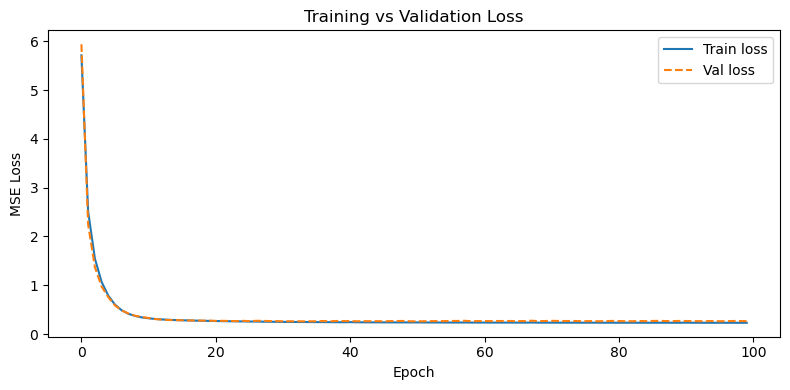

In [7]:
# --- Plot training and validation loss curves ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()